In [1]:
#| default_exp triangular

In [ ]:
#| export

import numpy as np
import igl
from scipy import spatial

In [ ]:
#| hide

import matplotlib.pyplot as plt

In [2]:
#| export

import jax
import jax.numpy as jnp

In [19]:
#| export

from jaxtyping import Bool, Float, Int 
from pathlib import Path

import dataclasses

In [5]:
#| export

from triangulax import trigonometry as trig

In [11]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [7]:
#| hide

import jaxtyping


In [8]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, disable type checks

## Loading, processing, and saving triangular meshes

`triangulax` is a library for working with triangular meshes using JAX. This notebook defines tools for loading, processing, and saving triangular meshes _outside_ of JAX. The dataclass `TriMesh` keeps the different pieces of a triangulation in one place. This module allows interfacing with JAX-external code, like the excellent `igl` geometry processing library, prepare initial conditions for simulations, etc. The data structure for the JAX-based code is defined in the `mesh` module, notebook 02.

### Cell tesselations and triangular meshes

One use case of `triangulax` is simulations of 2D cell tesselations. A convenient way to represent a cell tiling is by its _dual_ triangular mesh. Each cell becomes a triangulation vertex, and corners of the cell polygons become triangulation faces. This represents the connectivity of the cell tesselations by a 2D triangulation. For example, Voronoi tesselations can also be represented by their dual Delaunay triangulation.

### The `TriMesh` class

A `TriMesh` triangulation is a list of vertices and faces (triangles):

1. A set of vertices, i.e., a $(N_V, d)$ dimensional array datatype `float`, where $d$ is 2 or 3.
2. A set of faces, a $(N_F, 3)$ dimensional array of datatype `int`. Each row is an ordered triple of vertex indices that form a face.
3. (Optional) A set of face centers, a $(N_F, d)$ dimensional array of datatype `float`. An entry is the position of the dual vertex of the triangulation face (think circumcenter).

To read and write, we use the `.obj`-file format. We use the `igl` geometry processing library. The `TriMesh` class is a "holder" for loading, saving, and visualizing meshes, and not to be used for numerical computation.

### UV maps

To map 3D meshes into a 2D plane for visualization, one can use [UV maps](https://en.wikipedia.org/wiki/UV_mapping) (the triangular-mesh-equivalent of a coordinate parametrization for a 2D surface). UV maps can be read in from `.obj` files and are stored in the `TriMesh` object.

A UV map consists of:

1. **Texture vertices** (`texture_vertices`): a $(N_{TV}, 2)$ array of 2D coordinates. The number of texture vertices can differ from the number of mesh vertices (e.g. at seams, one mesh vertex maps to multiple UV positions).
2. **Texture faces** (`texture_faces`): a $(N_F, 3)$ array of texture vertex indices. `texture_faces[i]` corresponds to `faces[i]`.

The mapping between mesh vertices and texture vertices is provided by the `texture_vertex_to_vertex_map` and `vertex_to_texture_vertex_map` properties. These enable projecting per-vertex data (e.g. scalar fields, Laplacian eigenvectors) to the UV domain for 2D visualization.

In [9]:
#| export

_INF_SENTINEL = 1e300  # Sentinel for infinity vertices in .obj files

@dataclasses.dataclass(init=True, repr=False, eq=False, frozen=False, slots=False)
class TriMesh:
    """
    Simple class for reading, holding, transforming, and saving triangular meshes.
    
    A TriMesh comprises vertices and faces, describing a surface in 2d or 3d. 
    In addition, there can be a 2d/3d position for every face (think Voronoi dual of the triangulation).
    Optionally, a UV map (texture vertices and texture faces) can be stored for 3D-to-2D projection.
    
    Vertices and faces are jnp.arrays. Each face is a triple of vertex indices.
    Vertices and faces are ordered - this is essential so that we know which attribute
    vector entry goes to which vector/edge/face. Faces in a face are assumed to be in counter-clockwise order.

    Meshes are read and written in the .obj format (https://en.wikipedia.org/wiki/Wavefront_.obj_file).
    To store _face_positions_, we abuse the `vn` (vertex normal) entry of an .obj file. Face
    positions will be written in order corresponding to faces.
    When reading from an .obj file, edges are recomputed from faces and initialized in alpha-numerical ordering.
    An .obj file expects 3d positions; the z-position is ignored when reading and set to 0 when writing for 2d meshes.
    
    If the mesh has infinity vertices, a ``# triangulax: has_inf_vertex`` comment is written;
    on read, sentinel values are converted back to ``inf``. Vertices at "infinity" are used
    to implicitly represent mesh boundaries for numerical reasons.

    **Attributes**

    vertices : Float[jax.Array, "n_vertices dim"]

    faces : Int[jax.Array, "n_faces 3"]

    face_positions : Float[jax.Array, "n_faces dim"] | None

    texture_vertices : Float[jax.Array, "n_texture_vertices 2"] | None
        UV coordinates. Number of texture vertices can differ from number of mesh vertices.

    texture_faces : Int[jax.Array, "n_faces 3"] | None
        Texture vertex indices per face. ``texture_faces[i]`` corresponds to ``faces[i]``.

    **Property methods (use like attributes)**

    dim : int

    n_vertices : int

    has_inf_vertex : bool

    has_texture : bool

    texture_vertex_to_vertex_map : Int[jax.Array, "n_texture_vertices"]
        Entry ``i`` is the mesh vertex index corresponding to texture vertex ``i``.

    vertex_to_texture_vertex_map : Int[jax.Array, "n_vertices"]
        Entry ``i`` is a texture vertex index corresponding to mesh vertex ``i``.

    **Static methods**
    
    read_obj : str -> TriMesh

    **Methods**

    write_obj : str -> None
        
    """
    vertices : Float[jax.Array, "n_vertices dim"]
    faces : Int[jax.Array, "n_faces 3"]
    face_positions : Float[jax.Array, "n_faces dim"] | None = None
    texture_vertices : Float[jax.Array, "n_texture_vertices 2"] | None = None
    texture_faces : Int[jax.Array, "n_faces 3"] | None = None

    def set_voronoi(self):
        """Set face positions to the Voronoi dual of the faces is computed."""
        self.face_positions = jax.vmap(trig.get_circumcenter)(*[self.vertices[fcs] for fcs in self.faces.T])
        
    @staticmethod  
    def read_obj(filename: str | Path, read_face_positions: bool = False, dim: int = 2) -> "TriMesh":
        """
        Read vertices, texture vertices, normals, and faces from an obj file.

        Indices of returned faces start at 0. See https://en.wikipedia.org/wiki/Wavefront_.obj_file.
        Intended for .obj files containing a single object only.
        If the file contains a ``# triangulax: has_inf_vertex`` comment (written by
        :meth:`write_obj`), sentinel values are converted back to ``inf``.

        Parameters
        ----------
        filename : str
            filename
        read_face_positions : bool
            If True, use the vertex normal entries `vn` in the .obj file
            as face positions. This is an abuse of the .obj file format
            so only use this for files written by triangulax.
        dim : int
            Dimension - can be 2 or 3. If 2, the z-coordinate is ignored.
        
        Returns
        -------
        mesh: TriMesh
        """
        # Scan header for triangulax metadata
        has_inf_comment = False
        with open(filename, 'r') as f:
            for line in f:
                stripped = line.strip()
                if stripped and not stripped.startswith('#'):
                    break
                if 'triangulax: has_inf_vertex' in line:
                    has_inf_comment = True

        vertices, texture_verts, normals, faces, texture_fcs, _ = igl.readOBJ(filename)
        # Parse texture (UV) data
        if texture_verts.size == 0 or texture_fcs.size == 0:
            tex_v, tex_f = (None, None)
        else:
            tex_v = jnp.array(texture_verts[:, :2], dtype=jnp.float64)
            tex_f = jnp.array(texture_fcs, dtype=jnp.int64)

        verts = jnp.array(vertices[:, :dim], dtype=jnp.float64)
        if has_inf_comment:
            verts = jnp.where(jnp.abs(verts) > _INF_SENTINEL,
                              jnp.inf * jnp.ones_like(verts), verts)

        if read_face_positions:
            return TriMesh(verts, jnp.array(faces, dtype=jnp.int64),
                           face_positions=jnp.array(normals[:, :dim], dtype=jnp.float64),
                           texture_vertices=tex_v, texture_faces=tex_f)
        mesh = TriMesh(verts, jnp.array(faces, dtype=jnp.int64), face_positions=None,
                       texture_vertices=tex_v, texture_faces=tex_f)
        if dim == 2:
            mesh.set_voronoi()
        return mesh
        
    def write_obj(self, filename: str | Path, save_face_positions: bool = True) -> None:
        """
        Write mesh to .obj format.

        Texture vertices (if present) are written as ``vt`` lines with ``f v/vt`` face format.
        Face positions (if present and ``save_face_positions=True``) are always written as
        ``vn`` lines, regardless of whether UV data is present.
        If the mesh has infinity vertices, a ``# triangulax: has_inf_vertex`` comment is
        written and ``inf`` values are replaced by a sentinel for .obj compatibility.

        Parameters
        ----------
        filename : str
            filename to save to
        save_face_positions : bool
            If true, face positions are written to the ``vn`` lines of .obj files.
            
        Returns
        -------
        None
        """
        def _fmt3(v):
            """Format coordinates as 3D string, padding 2D with 0."""
            return "{} {} {}".format(*v) if len(v) == 3 else "{} {} 0".format(*v)

        vertices = np.array(self.vertices)
        if self.has_inf_vertex:
            vertices = np.where(np.isinf(vertices),
                                _INF_SENTINEL * np.ones_like(vertices), vertices)

        with open(filename, 'w') as f:
            # Metadata comments
            if self.has_inf_vertex:
                f.write("# triangulax: has_inf_vertex\n")
            if save_face_positions and self.face_positions is not None:
                f.write("# triangulax: vn-lines encode face centers, not normals\n")
            # Vertices
            for v in vertices:
                f.write(f"v {_fmt3(v)}\n")
            # Texture vertices
            if self.has_texture:
                for vt in self.texture_vertices:
                    f.write("vt {} {}\n".format(*vt))
            # Face positions as vn
            if save_face_positions and self.face_positions is not None:
                for vn in self.face_positions:
                    f.write(f"vn {_fmt3(vn)}\n")
            # Faces
            if self.has_texture:
                for fc, fct in zip(self.faces, self.texture_faces):
                    f.write("f {}\n".format(" ".join(
                        "{}/{}".format(int(v + 1), int(vt + 1))
                        for v, vt in zip(fc, fct))))
            else:
                for fc in self.faces:
                    f.write("f {}\n".format(" ".join(
                        str(int(v + 1)) for v in fc)))
        return None

    @property
    def has_texture(self) -> bool:
        """Check if mesh has UV (texture) information."""
        return self.texture_vertices is not None and self.texture_faces is not None

    @property
    def texture_vertex_to_vertex_map(self) -> Int[jax.Array, " n_texture_vertices"]:
        """Entry ``i`` is the mesh vertex index corresponding to texture vertex ``i``.

        Use to map per-vertex data to UV space, e.g.
        ``scalar_field[mesh.texture_vertex_to_vertex_map]``.
        """
        assert self.has_texture, "Requires texture (UV) information"
        pairs = np.unique(np.stack([np.array(self.texture_faces),
                                    np.array(self.faces)], axis=-1).reshape((-1, 2)), axis=0)
        return jnp.array(pairs[:, 1])

    @property
    def vertex_to_texture_vertex_map(self) -> Int[jax.Array, " n_vertices"]:
        """Entry ``i`` is a texture vertex index corresponding to mesh vertex ``i``.

        A vertex can map to multiple texture vertices (at seams); the first is returned.
        """
        assert self.has_texture, "Requires texture (UV) information"
        pairs = np.unique(np.stack([np.array(self.faces),
                                    np.array(self.texture_faces)], axis=-1).reshape((-1, 2)), axis=0)
        _, unique_indices = np.unique(pairs[:, 0], return_index=True)
        return jnp.array(pairs[unique_indices][:, 1])

    @property
    def has_inf_vertex(self) -> np.bool:
        return np.isinf(self.vertices).any()
    
    @property
    def inf_vertices(self) -> bool:
        return np.where(np.isinf(self.vertices))

    @property
    def n_vertices(self) -> int:
        return self.vertices.shape[0]

    @property
    def dim(self) -> int:
        return self.vertices.shape[-1]

In [10]:
# test reading a mesh

mesh = TriMesh.read_obj("../test_meshes/disk.obj")

  o flat_tri_ecmc


In [11]:
# test computing the circumcenter of each face. should be equidistant to all vertex points

dists = jnp.stack([jnp.linalg.norm(mesh.vertices[mesh.faces[:,i]]-mesh.face_positions, axis=1) for i in [0,1,2]], axis=1)

jnp.allclose(dists[:,0], dists[:,1]) and jnp.allclose(dists[:,1], dists[:,2])

Array(True, dtype=bool)

In [12]:
# test writing face positions to vn entries

mesh = TriMesh.read_obj("../test_meshes/disk.obj")
filename = "../test_meshes/disk_write_test.obj"
mesh.write_obj(filename, save_face_positions=True)
mesh = TriMesh.read_obj(filename, read_face_positions=True)

  o flat_tri_ecmc


In [13]:
# test reading a 3D mesh with UV map (sphere.obj has texture data from Blender)

mesh3d = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3)
assert mesh3d.has_texture, "sphere.obj should have UV data"
assert mesh3d.texture_vertices.shape[1] == 2, "texture_vertices should be 2D"
assert mesh3d.texture_faces.shape[0] == mesh3d.faces.shape[0], "texture_faces and faces must have same length"
print(f"Sphere: {mesh3d.n_vertices} vertices, {mesh3d.faces.shape[0]} faces, "
      f"{mesh3d.texture_vertices.shape[0]} texture vertices")

Sphere: 42 vertices, 80 faces, 63 texture vertices


  o Icosphere


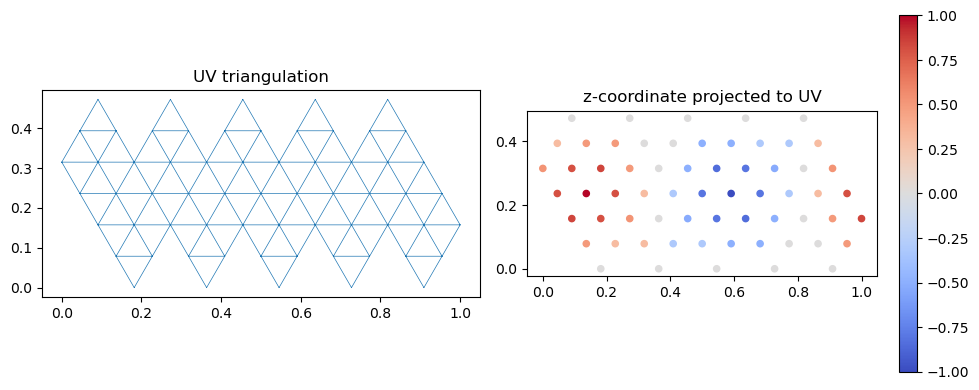

In [14]:
# test projecting vertex positions to UV space and plotting the UV map

positions_in_uv = mesh3d.vertices[mesh3d.texture_vertex_to_vertex_map]
assert positions_in_uv.shape == (mesh3d.texture_vertices.shape[0], 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.triplot(*mesh3d.texture_vertices.T, mesh3d.texture_faces, lw=0.5)
ax1.set_title("UV triangulation")
ax1.set_aspect("equal")

sc = ax2.scatter(*mesh3d.texture_vertices.T,
                 c=positions_in_uv[:, 2], cmap="coolwarm", s=20)
ax2.set_title("z-coordinate projected to UV")
ax2.set_aspect("equal")
plt.colorbar(sc, ax=ax2)
plt.tight_layout()

In [15]:
# test write/read roundtrip with UV data

mesh3d.write_obj("../test_meshes/sphere_write_test.obj")
mesh3d_reloaded = TriMesh.read_obj("../test_meshes/sphere_write_test.obj", dim=3)
assert mesh3d_reloaded.has_texture
assert jnp.allclose(mesh3d.texture_vertices, mesh3d_reloaded.texture_vertices, atol=1e-5)
assert jnp.array_equal(mesh3d.faces, mesh3d_reloaded.faces)
print("UV write/read roundtrip: OK")

UV write/read roundtrip: OK


In [16]:
# test that 2D meshes without UV still work as before

mesh2d = TriMesh.read_obj("../test_meshes/disk.obj")
assert not mesh2d.has_texture
assert mesh2d.face_positions is not None  # Voronoi computed automatically
print("2D mesh (no UV) backward compatibility: OK")

2D mesh (no UV) backward compatibility: OK


  o flat_tri_ecmc


In [17]:
#| export

def compute_per_face_jacobian(source_vertices: Float[jax.Array, "n_source_vertices d_source"],
                              source_faces: Int[jax.Array, "n_faces 3"],
                              target_vertices: Float[jax.Array, "n_target_vertices d_target"],
                              target_faces: Int[jax.Array, "n_faces 3"],
                              ) -> Float[jax.Array, "n_faces d_target d_source"]:
    """
    Compute per-face Jacobian matrix for a map between meshes.

    ``source_faces[i]`` is mapped to ``target_faces[i]``. The Jacobian maps
    tangent vectors of the source mesh to tangent vectors of the target mesh,
    evaluated per face via least-squares.

    Typical use: map gradients from a 3D mesh to its 2D UV parametrization::

        jac = compute_per_face_jacobian(mesh.vertices, mesh.faces,
                                        mesh.texture_vertices, mesh.texture_faces)
        gradient_2d = jnp.einsum('fij,fj->fi', jac, gradient_3d)

    Parameters
    ----------
    source_vertices : Float[jax.Array, "n_source_vertices d_source"]
        Source mesh vertices.
    source_faces : Int[jax.Array, "n_faces 3"]
        Source mesh faces (triangular).
    target_vertices : Float[jax.Array, "n_target_vertices d_target"]
        Target mesh vertices.
    target_faces : Int[jax.Array, "n_faces 3"]
        Target mesh faces (triangular).

    Returns
    -------
    jacobian : Float[jax.Array, "n_faces d_target d_source"]
        Per-face Jacobian matrices.
    """
    A = source_vertices[source_faces]  # (n_faces, 3, d_source)
    B = target_vertices[target_faces]  # (n_faces, 3, d_target)
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)

    def _solve_one(a, b):
        # a: (3, d_source), b: (3, d_target) -> (d_target, d_source)
        sol, _, _, _ = jnp.linalg.lstsq(a, b, rcond=None)
        return sol.T

    return jax.vmap(_solve_one)(A, B)

### Creating and plotting meshes

Some functions to create meshes based on the Delaunay triangulation of a point set.

1. Poisson (vertices placed uniformly at random) in disk or box
2. Ginibre (vertices placed at uniform with self-repulsion)
3. Triangular lattice

Some functions for plotting meshes:

1. Plot triangulation with vertex and face labels (for debugging)
2. Plot cell tesselation

In [8]:
#| export

def generate_ginibre_points(n_vertices: int) -> Float[jax.Array, "n_vertices 2"]:
    """Sample n_vertices points from the Ginibre ensemble. Points are scaled to unit disk."""
    M = np.random.normal(size=(n_vertices, n_vertices)) + 1j*np.random.normal(size=(n_vertices, n_vertices))
    vals = np.linalg.eigvals(M)
    pos = np.stack([vals.real, vals.imag], axis=-1)
    # rescale to unit disk
    pos /= np.linalg.norm(pos, axis=1).mean()
    return jnp.array(pos)

def generate_poisson_points(n_vertices: int, limit_x: float = 1, limit_y: float = 1
                           ) -> Float[jax.Array, "n_vertices 2"]:
    """Sample n_vertices points from the Poisson ensemble in rectangle
    [-limit_x/2, limit_x/2] * [-limit_y/2, limit_y/2]."""
    pos = np.stack([np.random.uniform(size=n_vertices, low=-limit_x/2, high=limit_x/2),
                    np.random.uniform(size=n_vertices, low=-limit_y/2, high=limit_y/2)])
    return jnp.array(pos.T)

def generate_triangular_lattice(nx: int, ny: int) -> Float[jax.Array, "nx*ny 2"]:
    """Get points for rectangular patch of triangular lattice with nx, ny points."""
    y = np.arange(0, ny)*np.sqrt(3)/2
    x = np.arange(nx).astype(float)
    X, Y = np.meshgrid(x, y)
    X -= X.mean()+1/2
    Y -=Y.mean()
    X = (X.T+(np.arange(ny)%2)/2).T
    pts = np.stack([X, Y]).reshape((2,nx*ny))    
    return jnp.array(pts.T)

(np.float64(-1.5158254775951099),
 np.float64(1.6648836832643656),
 np.float64(-1.5647768086089484),
 np.float64(1.5000093386295263))

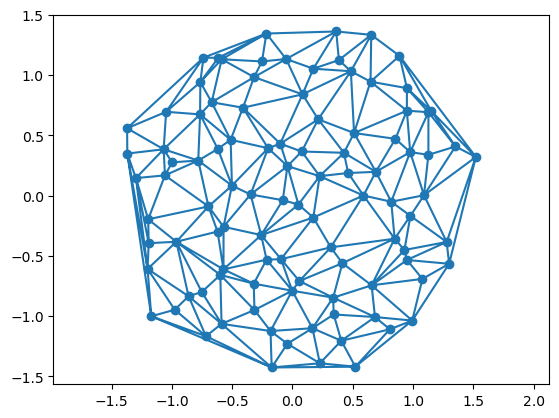

In [19]:
#points = generate_triangular_lattice(10, 10)

points = generate_ginibre_points(100)
mesh = TriMesh(vertices=points, faces=jnp.array(spatial.Delaunay(points).simplices))

plt.triplot(*points.T, mesh.faces)

plt.scatter(*points.T)
plt.axis("equal")

### Creating 2d meshes with periodic boundary conditions (PBCs)

In [15]:
#| export

def get_periodic_delaunay_faces(points: Float[jax.Array, "n_vertices 2"], L: Float[jax.Array, "2"],
                                ) -> Int[jax.Array, "n_faces 3"]:
    """Return faces of the periodic Delaunay triangulation on a rectangular torus.

    The input points are first wrapped into the fundamental domain
    ``[0, L_x) x [0, L_y)``. The point cloud is then tiled into the eight neighboring
    copies of the box, triangulated in the extended domain, and mapped back to the
    original vertex ids.

    Parameters
    ----------
    points : Float[jax.Array, "n_vertices 2"]
        Seed points in 2D. Points may lie outside the fundamental domain.
    L : Float[jax.Array, "2"]
        Domain size ``[L_x, L_y]`` with positive entries.

    Returns
    -------
    faces : Int[jax.Array, "n_faces 3"]
        Triangle indices for the periodic Delaunay triangulation of the wrapped points.
    """
    points_np = np.asarray(points, dtype=float)
    L_np = np.asarray(L, dtype=float)

    wrapped_points = np.mod(points_np, L_np[None, :])
    n_vertices = wrapped_points.shape[0]
    rounded_points = np.round(wrapped_points, decimals=12)
    assert np.unique(rounded_points, axis=0).shape[0] == n_vertices, (
        "points must remain distinct after wrapping into the periodic box")

    shifts = np.array([[dx, dy]
                       for dx in (-L_np[0], 0.0, L_np[0])
                       for dy in (-L_np[1], 0.0, L_np[1])], dtype=float)
    tiled_points = np.concatenate([wrapped_points + shift[None, :] for shift in shifts], axis=0)
    origin_ids = np.tile(np.arange(n_vertices, dtype=np.int64), shifts.shape[0])

    simplices = spatial.Delaunay(tiled_points).simplices
    simplex_centers = tiled_points[simplices].mean(axis=1)
    keep = np.all((simplex_centers >= 0.0) & (simplex_centers < L_np[None, :]), axis=1)
    faces = origin_ids[simplices[keep]]
    distinct_vertices = np.all(np.diff(np.sort(faces, axis=1), axis=1) > 0, axis=1)
    faces = faces[distinct_vertices]

    _, unique_idx = np.unique(np.sort(faces, axis=1), axis=0, return_index=True)
    faces = faces[np.sort(unique_idx)]

    edge_ab = wrapped_points[faces[:, 1]] - wrapped_points[faces[:, 0]]
    edge_ac = wrapped_points[faces[:, 2]] - wrapped_points[faces[:, 0]]
    edge_ab -= L_np[None, :] * np.round(edge_ab / L_np[None, :])
    edge_ac -= L_np[None, :] * np.round(edge_ac / L_np[None, :])
    signed_area = edge_ab[:, 0] * edge_ac[:, 1] - edge_ab[:, 1] * edge_ac[:, 0]
    nondegenerate = ~np.isclose(signed_area, 0.0)
    faces = faces[nondegenerate]
    signed_area = signed_area[nondegenerate]

    faces = np.array(faces, copy=True)
    flip = signed_area < 0
    faces[flip] = faces[flip][:, [0, 2, 1]]
    return jnp.array(faces, dtype=jnp.int64)

In [20]:
#| export

def get_faces_crossing_periodic_boundaries(vertices: Float[jax.Array, "n_vertices 2"],
                                           faces: Int[jax.Array, "n_faces 3"],
                                           L_x: float, L_y: float,
                                           ) -> Int[jax.Array, "n_faces"]:
    """Return a boolean mask for faces that cross a periodic box boundary.

    A face is marked as boundary-crossing if at least one of its edges is shorter
    under the minimum-image convention than in the direct coordinates inside the
    fundamental domain.

    Parameters
    ----------
    vertices : Float[jax.Array, "n_vertices 2"]
        Vertex positions. They may lie outside the fundamental domain and are wrapped
        into ``[0, L_x) x [0, L_y)`` internally.
    faces : Int[jax.Array, "n_faces 3"]
        Triangle indices.
    L_x, L_y : float
        Side lengths of the rectangular periodic domain.

    Returns
    -------
    crosses_boundary : Bool[jax.Array, "n_faces"]
        Boolean mask whose entry ``i`` is True when ``faces[i]`` crosses a domain boundary.
    """
    vertices_np = np.asarray(vertices, dtype=float)
    faces_np = np.asarray(faces, dtype=np.int64)
    L = np.array([L_x, L_y], dtype=float)
    assert np.all(L > 0), "box lengths must be positive"

    wrapped_vertices = np.mod(vertices_np, L[None, :])
    face_vertices = wrapped_vertices[faces_np]
    edge_vectors = np.stack([face_vertices[:, 1] - face_vertices[:, 0],
                             face_vertices[:, 2] - face_vertices[:, 1],
                             face_vertices[:, 0] - face_vertices[:, 2]], axis=1)
    periodic_edge_vectors = edge_vectors - L[None, None, :] * np.round(edge_vectors / L[None, None, :])
    crosses_boundary = np.any(~np.isclose(edge_vectors, periodic_edge_vectors), axis=(1, 2))
    return jnp.array(crosses_boundary, dtype=bool)

Text(0.5, 1.0, 'Periodic Delaunay triangulation')

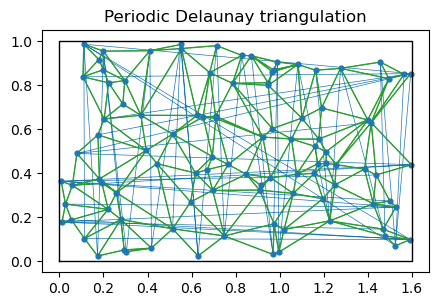

In [26]:
L = jnp.array([1.6, 1.0])
points = generate_poisson_points(100, *L)
wrapped_points = jnp.mod(points, L[None, :])
faces = get_periodic_delaunay_faces(points, L)
crosses_boundary = get_faces_crossing_periodic_boundaries(wrapped_points, faces, *L)

plt.figure(figsize=(5, 4))
plt.triplot(*wrapped_points.T, faces, lw=0.5)
plt.triplot(*wrapped_points.T, faces[~crosses_boundary], lw=1)


plt.scatter(*wrapped_points.T, s=12)
plt.plot([0, L[0], L[0], 0, 0], [0, 0, L[1], L[1], 0], c="black", lw=1)
plt.gca().set_aspect("equal")
plt.xlim(-0.05 * L[0], 1.05 * L[0])
plt.ylim(-0.05 * L[1], 1.05 * L[1])
plt.title("Periodic Delaunay triangulation")

In [27]:
for n_vertices in [32, 64, 96]:
    L = jnp.array([1.7, 1.1])
    points = generate_poisson_points(n_vertices, *L)
    wrapped_points = jnp.mod(points, L[None, :])
    faces = np.array(get_periodic_delaunay_faces(points, L))
    crosses_boundary = np.array(get_faces_crossing_periodic_boundaries(wrapped_points, faces, *L))

    assert faces.ndim == 2 and faces.shape[1] == 3
    assert np.all(np.diff(np.sort(faces, axis=1), axis=1) > 0)
    assert crosses_boundary.shape == (faces.shape[0],)
    assert (~crosses_boundary).any()
    assert igl.is_edge_manifold(faces)[0]
    assert igl.is_vertex_manifold(faces)[0]
    assert len(igl.boundary_loop_all(faces)) == 0

print("Periodic Delaunay triangulations are manifold and boundary-free.")

Periodic Delaunay triangulations are manifold and boundary-free.


### Elementary book-keeping using list-of-triangles data structure

In [20]:
#| export

# find the vertices and faces which are adjacent to a given vertex, in the correct counter-clockwise order.

def get_adjacent_vertex_indices(faces: Int[jax.Array, "n_faces 3"],
                                n_vertices: int) -> list[Int[jax.Array, " n_neighbors"]]:
    """For each vertex, get the indices of the adjacent vertices in correct order.
    For boundary vertices, this list contains the vertex itself."""
    faces = np.array(faces)
    vf, ni = igl.vertex_triangle_adjacency(faces, n=n_vertices)
    adjacent_faces = [vf[a:b] for a, b in zip(ni[:-1], jnp.roll(ni, -1)[:-1])]
    adjacent_vertices = [jnp.array(igl.boundary_loop(faces[fcs])) for fcs in adjacent_faces]
    return adjacent_vertices

In [22]:
mesh = TriMesh.read_obj("../test_meshes/disk.obj")

neighbors = get_adjacent_vertex_indices(mesh.faces, mesh.n_vertices)

  o flat_tri_ecmc
